# Results and Conclusions

As stated in our Problem Description section, the task at hand aimed to generate accurate multi-horizon forecasts across three distinct test periods to ensure robust model validation and avoid overfitting:

- **Test Period 1:** October – December 2024
- **Test Period 2:** January – March 2025
- **Test Period 3:** July – September 2025

Each model was trained exclusively on data preceding its respective test period, enabling evaluation across varying market conditions. Performance metrics are averaged across all three folds to establish true model performance.

In this section we evaluate the results accross all models. 

## Best Performing Models

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("../docs/results/all_results.parquet")

# Create model identifier 
df['model_id'] = df['Model'] + '_' + df['Approach'] + '_' + df['Features']

df

,Model,Approach,Features,Fold,MSE,RMSE,MAE,R2,SMAPE,model_id
0,RNN,Uni,noExog,Fold1,90146.77,300.24,123.29,0.8384,68.94,RNN_Uni_noExog
1,RNN,Uni,noExog,Fold2,72547.65,269.35,116.39,0.8553,68.59,RNN_Uni_noExog
2,RNN,Uni,noExog,Fold3,68480.28,261.69,106.51,0.8696,64.13,RNN_Uni_noExog
3,RNN,Uni,noExog,Average,77058.23,277.10,115.40,0.8544,67.22,RNN_Uni_noExog
4,RNN,Uni,noExog,Standard Deviation,11088.68,19.82,8.50,0.0156,2.51,RNN_Uni_noExog
...,...,...,...,...,...,...,...,...,...,...
130,Transformer,Multi,Exog,Fold1,255446.32,505.42,438.53,0.4938,136.59,Transformer_Multi_Exog
131,Transformer,Multi,Exog,Fold2,279882.45,529.04,483.49,0.3820,139.74,Transformer_Multi_Exog
132,Transformer,Multi,Exog,Fold3,86907.71,294.80,144.08,0.8213,114.67,Transformer_Multi_Exog
133,Transformer,Multi,Exog,Average,207412.16,443.09,355.36,0.5657,130.33,Transformer_Multi_Exog


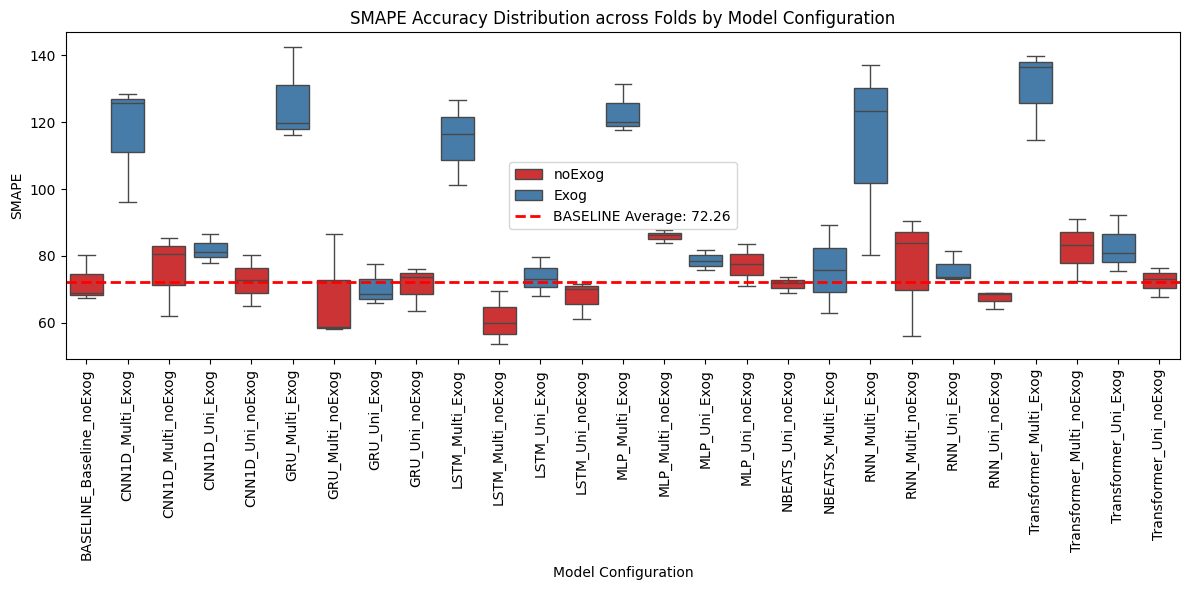

In [10]:
# Get the Average SMAPE for BASELINE model
baseline_smape = df[(df['Model'] == 'BASELINE') & (df['Fold'] == 'Average')]['SMAPE'].values[0]
data = df[~df['Fold'].isin(['Average', 'Standard Deviation'])].copy().sort_values(by='model_id')

# Plot SMAPE accuracy for "Average" Folds
plt.figure(figsize=(12, 6))
sns.boxplot(x='model_id', y='SMAPE', data=data, palette='Set1', hue='Features')
plt.axhline(y=baseline_smape, color='red', linestyle='--', linewidth=2, label=f'BASELINE Average: {baseline_smape:.2f}')
plt.xticks(rotation=90)
plt.title('SMAPE Accuracy Distribution across Folds by Model Configuration')
plt.xlabel('Model Configuration')
plt.ylabel('SMAPE')
plt.legend()
plt.tight_layout()
plt.show()

The multi-box plot visualization reveals different key insights:

**Impact of Exogenous Features**

We can observe, as stated in the previous chapter, that contrary to initial expectations the performance of most models decreased when added the exogenous features. This indicates that the additional information found in the exogenous features did not have significant effect on the number of registered vehicles. 

**Top-Performing Architectures**

Only three model configurations consistently outperformed the baseline across all three folds, with their entire boxplot distributions (including whiskers) falling below the 72.26% SMAPE threshold: (1) RNN_Uni_noExog, (2) LSTM_Multi_noExog, and (3) LSTM_Uni_noExog. This strong performance stems from the recurrent architectures' ability to capture temporal dependencies within the 6-month lookback window `seq_length`, combined with the 1-month embargo period that prevented information leakage. The LSTM and RNN cells' gating mechanisms effectively learned seasonal patterns and trend information from the compact sequence length.

**Multivariate vs. Univariate Superiority** 

The LSTM_Multi_noExog configuration emerged as the best-performing model with an average SMAPE of 61.03%, representing a **15.5% relative improvement** over the baseline and a **9.8% relative improvement** (6.64 percentage points) compared to its univariate counterpart (LSTM_Uni_noExog at 67.67% SMAPE). This substantial gain was achieved solely through architectural changes in data batching, no modifications to the LSTMForecaster model itself. 

The multivariate vectorized approach (`TimeSeriesDatasetVectorizedExog`) enables cross-series learning by processing all 1,502 time series simultaneously within each batch, allowing the model to identify common temporal patterns and interdependencies. In contrast, the univariate one-hot encoded approach (`TimeSeriesDataset`) treats each series independently, limiting knowledge transfer. 

This validates our hypothesis from the Modelling Approach section: **efficient batching strategies can unlock performance gains equivalent to architectural innovations**, reducing computational cost while improving forecast accuracy.


**Computational Efficiency Gains** 

Beyond accuracy improvements, the multivariate vectorized approach reduced training time by **1,502x** (from 124,666 to 83 training samples) while maintaining full exogenous feature support. This demonstrates that the batching strategy directly impacts both model performance and scalability critical considerations for production deployment with thousands of time series.


## Limitations

While our modeling framework demonstrated significant improvements over the baseline, several methodological and architectural constraints require some further analysis, we highlight five key aspects:

### 1. Exogenous Feature Engineering and Selection

The consistently poor performance of models incorporating exogenous features suggests limitations in our feature engineering approach rather than inherent irrelevance of macroeconomic indicators. We employed feature transformation like year-to-year and lagged features without exploring:

- Interaction terms between temporal and economic variables
- Feature selection techniques (e.g., mutual information, recursive feature elimination)

This indicates that more sophisticated feature engineering could unlock the predictive power of exogenous variables, particularly for models like NBEATSx designed to leverage external regressors.

### 2. Memory-Inefficient Sequence Generation (Lazy sequence generation)

Our implementation of `TimeSeriesDatasetVectorizedExog` lacks the **pointer-based indexing strategy** employed by Nixtla's production-grade framework. Instead of storing pre-materialized sequences in memory, Nixtla's approach uses indptr arrays to generate windows on-the-fly during training [Ref](https://github.com/Nixtla/neuralforecast/blob/main/neuralforecast/tsdataset.py):

```python
# Our approach (memory-intensive):
# Pre-materialize all sequences: (83 samples, 1502 series, 6 timesteps, n_features)
X = torch.tensor(all_sequences)  # ~500MB-2GB depending on features

# Nixtla's approach (memory-efficient):
# Store raw temporal data + index pointers
self.temporal = torch.tensor(raw_timeseries)  # (140,000 observations, n_features)
self.indptr = np.array([0, 93, 186, ...])     # (1503,) pointer array
# Generate windows dynamically in __getitem__
```

This architectural limitation restricts scalability—our approach consumes **O(n_series × n_windows × seq_length)** memory, whereas Nixtla's pointer-based method requires only **O(n_observations)** storage. For datasets with millions of time series or longer histories, our implementation would face memory constraints that could be mitigated through lazy sequence generation.

### 3. Limited Hyperparameter Exploration

Computational constraints restricted hyperparameter optimization to **5 Optuna trials per architecture**, focusing on a narrow search space. We could extend the hyperparameter search to a broader spectrum, e.g. 20 trials, to allow the model to search for more possible hyperparameters. 

### 4. Fixed Temporal Architecture

Our framework enforces a **fixed sequence length of 6 months** and **1-month embargo period** across all models and time series, ignoring the heterogeneity in optimal lookback windows across different vehicle segments. We could split our timeseries based on the volatility as following:

- High-volume stable series (e.g., popular sedans) benefit from shorter lookback windows (3-4 months)
- Low-volume volatile series (e.g., luxury EVs) require longer historical context (12+ months)
- Seasonal patterns vary by powertrain type (e.g., diesel registrations peak differently than EVs)

Implementing **adaptive sequence lengths** per time series could improve model flexibility.

### 5. Absence of Uncertainty Quantification

All models produce **point forecasts without probabilistic intervals**, limiting practical deployment value. Production forecasting systems require:

- **Prediction intervals** to communicate forecast reliability (e.g., 80%, 95% confidence bounds)
- **Quantile forecasts** for risk-aware decision making (e.g., worst-case inventory planning)

## Conclusions

### Learning Process and Technical Insights

This project served as a comprehensive exploration of neural network architectures for time series forecasting, developed as the final project for the course *Supervised and Unsupervised Learning*. The scope encompassed the full spectrum of sequence modeling approaches—from foundational Multi-Layer Perceptrons to sophisticated Transformer architectures—providing hands-on experience with eight distinct neural network families (MLP, RNN, LSTM, GRU, CNN1D, Transformer, N-BEATS, and NBEATSx).

#### Technical Insights

**End-to-End PyTorch Implementation**: Building production-grade forecasting pipelines from scratch, including custom Dataset classes, training loops with early stopping, gradient clipping, and learning rate scheduling. This low-level implementation provided deeper insights into model behavior than high-level frameworks like scikit-learn or Keras would permit.

**Data Loading Architecture**: A critical breakthrough was understanding how **batching strategies fundamentally impact model performance**. We discovered that the multivariate vectorized approach (`TimeSeriesDatasetVectorizedExog`) achieved **1,502x sample reduction** (from 124,666 to 83 training samples) while simultaneously improving forecast accuracy by 9.8%. This validates that **data organization can be as impactful as architectural innovation**.

**Experiment Tracking and Reproducibility**: Using Weights & Biases for experiment management demonstrated the necessity of systematic tracking in deep learning research. With 24 model configurations × 3 folds × multiple training runs, manual record-keeping would have been infeasible. This experience emphasized that MLOps practices are essential for research rigor, not just production deployment.

#### Conceptual Insights

Beyond technical implementation, the project revealed fundamental principles about neural network forecasting:

- **Recurrent architectures (LSTM, RNN) excel at short-sequence learning** (6-month lookback), contradicting the common belief that Transformers universally outperform RNNs. The gating mechanisms in LSTMs proved more effective than self-attention for this problem scale.

- **Cross-series learning through multivariate batching** enabled knowledge transfer across 1,502 time series, suggesting that global patterns (seasonality, trend dynamics) can be captured even when individual series have sparse data. This architectural insight could generalize to other multi-series forecasting domains (retail demand, energy consumption, financial markets).

- **Exogenous features require domain-specific engineering**: The failure of raw economic indicators to improve forecasts highlighted that **feature engineering is not architecture-agnostic**. Models designed for exogenous inputs (NBEATSx) still underperformed when features lacked proper temporal alignment or causal relationships with the target variable.

This project bridged the gap between theoretical neural network knowledge and practical forecasting implementation, demonstrating that successful deep learning applications require equal attention to data engineering, computational efficiency, and architectural design.